In [1]:
!git clone https://github.com/kamalkraj/DATA-SCIENCE-BOWL-2018.git
!unzip -q /content/DATA-SCIENCE-BOWL-2018/data/stage1_test.zip -d /content/test
!unzip -q /content/DATA-SCIENCE-BOWL-2018/data/stage1_train.zip -d /content/train

Cloning into 'DATA-SCIENCE-BOWL-2018'...
remote: Enumerating objects: 106, done.
remote: Total 106 (delta 0), reused 0 (delta 0), pack-reused 106 (from 1)
Receiving objects: 100% (106/106), 80.38 MiB | 26.45 MiB/s, done.
Resolving deltas: 100% (56/56), done.


#### 1. Import Libraries:

In [2]:
import os
import tensorflow as tf
from tensorflow import keras
#--
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
#---
from skimage.transform import resize
from skimage.io import imread, imshow

#Reproducibility
seed = 42
random.seed = seed
np.random.seed = seed

#### 1.2 Paths & quick inspect

In [3]:
IMG_WIDTH = 128
IMG_HEIGHT = 128
IMG_CHANNELS = 3

train_dir = r'/content/train'
test_dir = r'/content/test'

print('Train Length: ',len(next(os.walk(train_dir))[1]))
print('Test Length: ',len(next(os.walk(test_dir))[1]))

Train Length:  670
Test Length:  65


#### 2. Data Prepration

#### Collect our file names for training and test date

In [4]:
train_ids = next(os.walk(train_dir))[1]
test_ids = next(os.walk(test_dir))[1]

#### Create Train And Test Set:

In [5]:
#-------------------------------------------------------Train Set

print('Getting and Resizing Train Images ... ')
X_train = np.zeros((len(train_ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.uint8)
Y_train = np.zeros((len(train_ids), IMG_HEIGHT, IMG_WIDTH, 1), dtype='bool')

#------------------------Images
for n, id_ in tqdm(enumerate(train_ids), total=len(train_ids)):
    path = os.path.join(train_dir, id_)
    img = imread(path + '/images/' + id_ + '.png')[:,:,:IMG_CHANNELS]
    img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
    X_train[n] = img

    #----------------Masks
    mask = np.zeros((IMG_HEIGHT, IMG_WIDTH, 1), dtype=bool)
    # Now we take all masks associated with that image and combine them into one single mask

    for mask_file in next(os.walk(os.path.join(path + '/masks/')))[2]:
        mask_ = imread(path + '/masks/' + mask_file)
        mask_ = np.expand_dims(resize(mask_, (IMG_HEIGHT, IMG_WIDTH), mode='constant',
                                      preserve_range=True), axis=-1)
        mask = np.maximum(mask, mask_)
    # Y_train is now our single mask associated with our image
    Y_train[n] = mask

#-------------------------------------------------------Test Set

X_test = np.zeros((len(test_ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.uint8)
sizes_test = []
print('Getting and Resizing Test Images ...')

for n, id_ in tqdm(enumerate(test_ids), total=len(test_ids)):
    path = os.path.join(test_dir, id_)
    img = imread(path + '/images/' + id_ + '.png')[:,:,:IMG_CHANNELS]
    sizes_test.append([img.shape[0], img.shape[1]])
    img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
    X_test[n] = img

Getting and Resizing Train Images ... 


  0%|          | 0/670 [00:00<?, ?it/s]

Getting and Resizing Test Images ...


  0%|          | 0/65 [00:00<?, ?it/s]

#### Image and Mask Visualization

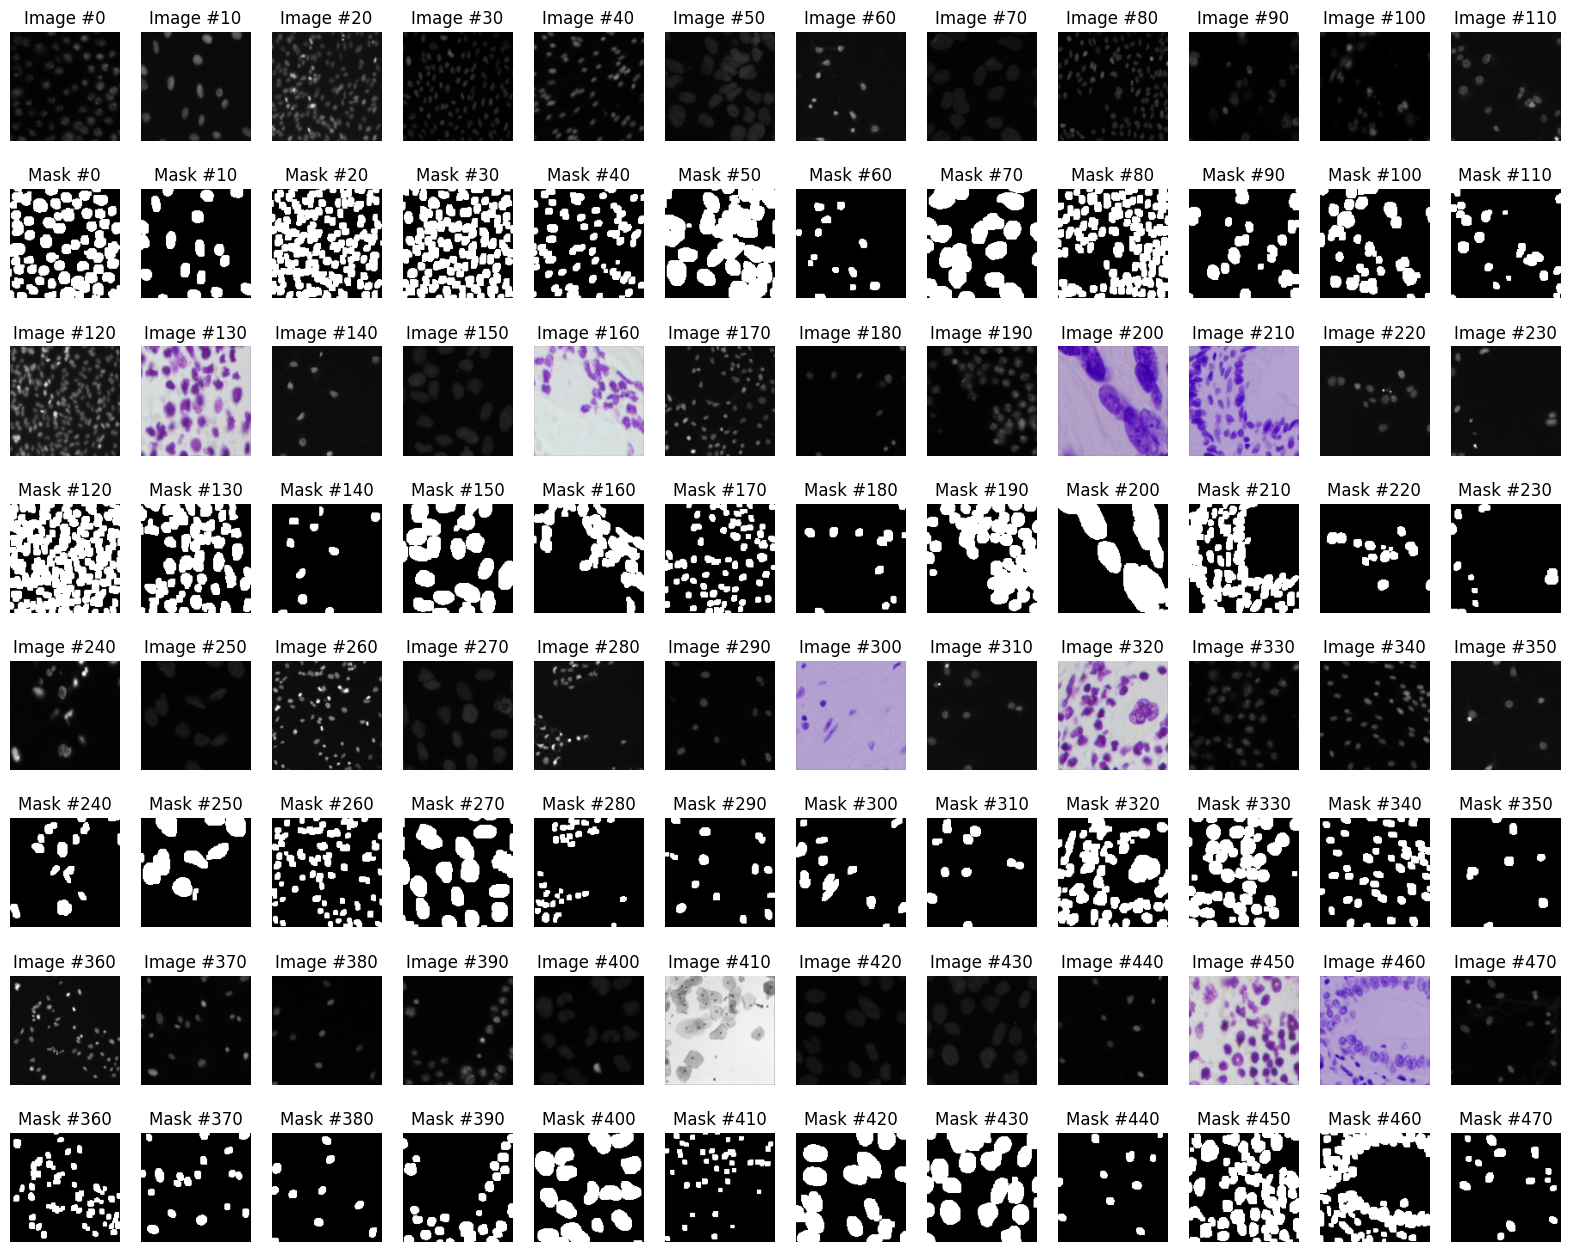

In [6]:
# Illustrate the train images and masks
plt.figure(figsize=(20,16))
x, y = 12,4
for i in range(y):
    for j in range(x):
        plt.subplot(y*2, x, i*2*x+j+1)
        pos = i*120 + j*10
        plt.imshow(X_train[pos])
        plt.title('Image #{}'.format(pos))
        plt.axis('off')
        plt.subplot(y*2, x, (i*2+1)*x+j+1)

        #We display the associated mask we just generated above with the training image
        plt.imshow(np.squeeze(Y_train[pos]), cmap='gray')
        plt.title('Mask #{}'.format(pos))
        plt.axis('off')

plt.show()

#### Using Metrics:
##### 1- Pixel Accuracy
##### 2- IOU
##### 3- Dice Coef

In [7]:
# We Used Dice Coef Metric:
def dice_coef(y_pred, y_true, smooth=1):
    y_pred_f = keras.backend.flatten(y_pred)
    y_true_f = keras.backend.flatten(y_true)
    y_pred_f = keras.backend.cast(y_pred_f, "float32")
    y_true_f = keras.backend.cast(y_true_f, "float32")
    intersection = keras.backend.sum(y_true_f * y_pred_f)
    output = (2 * intersection + smooth) / (keras.backend.sum(y_true_f) + keras.backend.sum(y_pred_f) + smooth)
    return output

#### 3. Build Unet Model:

In [8]:
#------------------------------------------------------------ Encoder Module:

inputs = keras.layers.Input(shape=(128, 128, 3)) # 3 channel for input images:
s = keras.layers.Lambda(lambda x: x / 255.0)(inputs)


#Block 1:
c1 = keras.layers.Conv2D(16, 3, activation='relu', padding='same')(s) #128x128x16
c1 = keras.layers.Dropout(0.1)(c1)
c1 = keras.layers.Conv2D(16, 3, activation='relu', padding='same')(c1) #128x128x16
p1 = keras.layers.MaxPool2D(pool_size=(2, 2))(c1) #64x64x16
#---

#Block 2:
c2 = keras.layers.Conv2D(32, 3, activation='relu', padding='same')(p1) #64x64x32
c2 = keras.layers.Dropout(0.1)(c2)
c2 = keras.layers.Conv2D(32, 3, activation='relu', padding='same')(c2) #64x64x32
p2 = keras.layers.MaxPool2D(pool_size=(2, 2))(c2) #32x32x32
#---

#Block 3:
c3 = keras.layers.Conv2D(64, 3, activation='relu', padding='same')(p2) #32x32x64
c3 = keras.layers.Dropout(0.2)(c3)
c3 = keras.layers.Conv2D(64, 3, activation='relu', padding='same')(c3) #32x32x64
p3 = keras.layers.MaxPool2D(pool_size=(2, 2))(c3) #16x16x64
#---

#Block 4:
c4 = keras.layers.Conv2D(128, 3, activation='relu', padding='same')(p3) #16x16x128
c4 = keras.layers.Dropout(0.2)(c4)
c4 = keras.layers.Conv2D(128, 3, activation='relu', padding='same')(c4) #16x16x128
p4 = keras.layers.MaxPool2D(pool_size=(2, 2))(c4) #8x8x128
#---

#Latent Space
c5 = keras.layers.Conv2D(256, 3, activation='relu', padding='same')(p4) #8x8x256
c5 = keras.layers.Dropout(0.3)(c5)
c5 = keras.layers.Conv2D(256, 3, activation='relu', padding='same')(c5) #8x8x256


#------------------------------------------------------------ Decoder Module:

#Block 4
u6 = keras.layers.Conv2DTranspose(128, 2, strides=2, padding='same')(c5) #16x16x128
u6 = keras.layers.Concatenate()([u6, c4]) #16x16x256
c6 = keras.layers.Conv2D(128, 3, activation='relu', padding='same')(u6) #16x16x128
c6 = keras.layers.Dropout(0.2)(c6)
c6 = keras.layers.Conv2D(128, 3, activation='relu', padding='same')(c6) #16x16x128


#Block 3
u7 = keras.layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c6) #32x32x64
u7 = keras.layers.Concatenate()([u7, c3]) #32x32x128
c7 = keras.layers.Conv2D(64, 3, activation='relu', padding='same')(u7) #32x32x64
c7 = keras.layers.Dropout(0.2)(c7)
c7 = keras.layers.Conv2D(64, 3, activation='relu', padding='same')(c7) #32x32x64


#Block 2
u8 = keras.layers.Conv2DTranspose(32, 2, strides=2, padding='same')(c7) #64x64x32
u8 = keras.layers.Concatenate()([u8, c2]) #64x64x64
c8 = keras.layers.Conv2D(32, 3, activation='relu', padding='same')(u8) #64x64x32
c8 = keras.layers.Dropout(0.2)(c8)
c8 = keras.layers.Conv2D(32, 3, activation='relu', padding='same')(c8) #64x64x32

#Block 1
u9 = keras.layers.Conv2DTranspose(16, 2, strides=2, padding='same')(c8) #128x128x16
u9 = keras.layers.Concatenate()([u9, c1]) #128x128x32
c9 = keras.layers.Conv2D(16, 3, activation='relu', padding='same')(u9) #128x128x16
c9 = keras.layers.Dropout(0.2)(c9)
c9 = keras.layers.Conv2D(16, 3, activation='relu', padding='same')(c9) #128x128x16

# Output
outputs = keras.layers.Conv2D(1, 1, activation='sigmoid')(c9) # 128x128x1

model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ lambda[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16, 16,    │          0 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    147,584 │ dropout_3[0][0] 

 Total params: 1,941,105 (7.40 MB)

 Trainable params: 1,941,105 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

#### Compile - Callbacks Anf Fit Unet Model:

In [9]:
#Compile:
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=[dice_coef])

# Initialize our callbacks
model_path = "./nuclei_finder_unet_1.keras"
checkpoint = keras.callbacks.ModelCheckpoint(model_path,
                             monitor="val_loss",
                             mode="min",
                             save_best_only = True,
                             verbose=1)

earlystop = keras.callbacks.EarlyStopping(monitor = 'val_loss',
                          min_delta = 0,
                          patience = 5,
                          verbose = 1,
                          restore_best_weights = True)

# Fit our model
results = model.fit(X_train, Y_train, validation_split=0.1,
                    batch_size=16, epochs=100,
                    callbacks=[earlystop, checkpoint])

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - dice_coef: 0.3057 - loss: 0.6288
Epoch 1: val_loss improved from None to 0.43134, saving model to ./nuclei_finder_unet_1.keras

Epoch 1: finished saving model to ./nuclei_finder_unet_1.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 47s 603ms/step - dice_coef: 0.2994 - loss: 0.5614 - val_dice_coef: 0.3881 - val_loss: 0.4313
Epoch 2/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - dice_coef: 0.4275 - loss: 0.3652
Epoch 2: val_loss improved from 0.43134 to 0.25676, saving model to ./nuclei_finder_unet_1.keras

Epoch 2: finished saving model to ./nuclei_finder_unet_1.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - dice_coef: 0.4840 - loss: 0.3356 - val_dice_coef: 0.6484 - val_loss: 0.2568
Epoch 3/100
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - dice_coef: 0.6901 - loss: 0.2201
Epoch 3: val_loss improved from 0.25676 to 0.17070, saving model to ./nuclei_finder_unet_1.keras

Epoch 3: finished saving model to ./nuclei_finder_unet_1.keras
38/38 ━━━━━━━━━━━━━━

#### 4. Load And Test Model:

In [15]:
model = keras.models.load_model(
    'nuclei_finder_unet_1.keras',
    custom_objects={'dice_coef': dice_coef},
    safe_mode=False
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ lambda[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16, 16,    │          0 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    147,584 │ dropout_3[0][0] 

 Total params: 5,823,317 (22.21 MB)

 Trainable params: 1,941,105 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,882,212 (14.81 MB)

#### Test Model On Train And Test set:

In [11]:
# the first 90% was used for training
preds_train = model.predict(X_train[:int(X_train.shape[0]*0.9)], verbose=1)

# the last 10% used as validation
preds_val = model.predict(X_train[int(X_train.shape[0]*0.9):], verbose=1)

#preds_test = model.predict(X_test, verbose=1)

# Threshold predictions
preds_train_t = (preds_train > 0.5).astype(np.uint8)
preds_val_t = (preds_val > 0.5).astype(np.uint8)

19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 159ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 292ms/step


#### Test Model On Train_Set

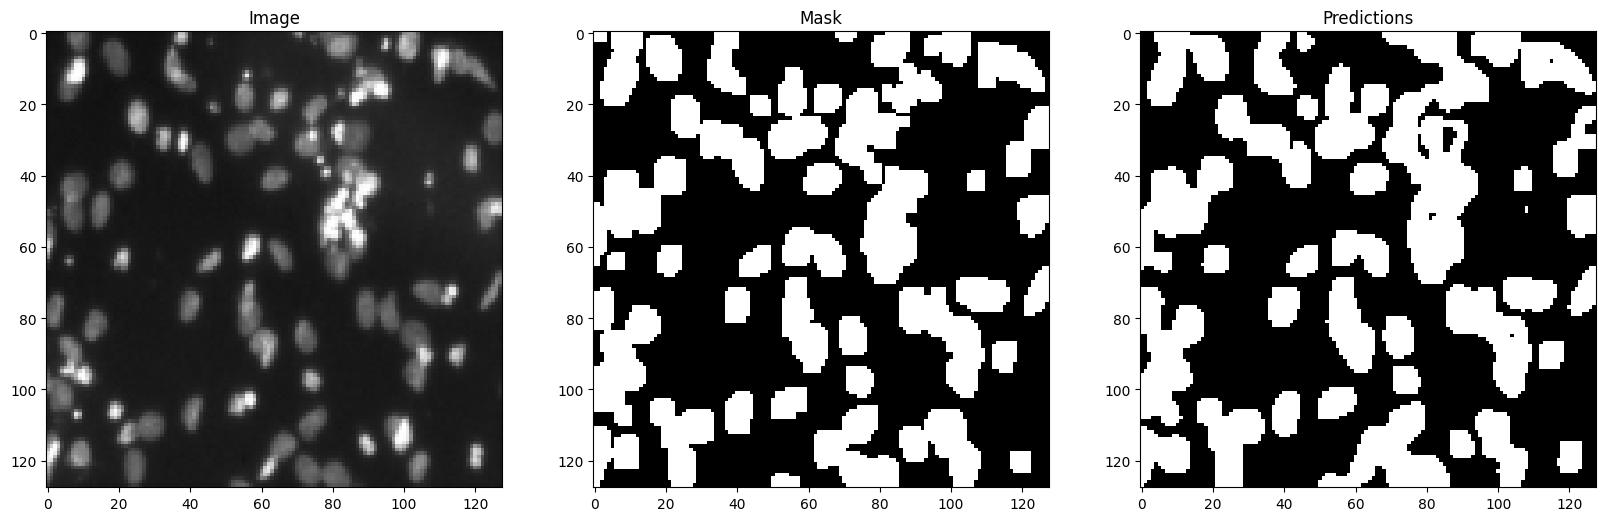

In [12]:
# Ploting our predicted masks
ix = random.randint(0, 602)
plt.figure(figsize=(20,20))

# Our original training image
plt.subplot(131)
plt.imshow(X_train[ix])
plt.title("Image")

# Our original combined mask
plt.subplot(132)
plt.imshow(np.squeeze(Y_train[ix]), cmap='gray')
plt.title("Mask")

# The mask our U-Net model predicts
plt.subplot(133)
plt.imshow(np.squeeze(preds_train_t[ix]  > 0.5), cmap='gray')
plt.title("Predictions")
plt.show()

#### Test Model On TestSet

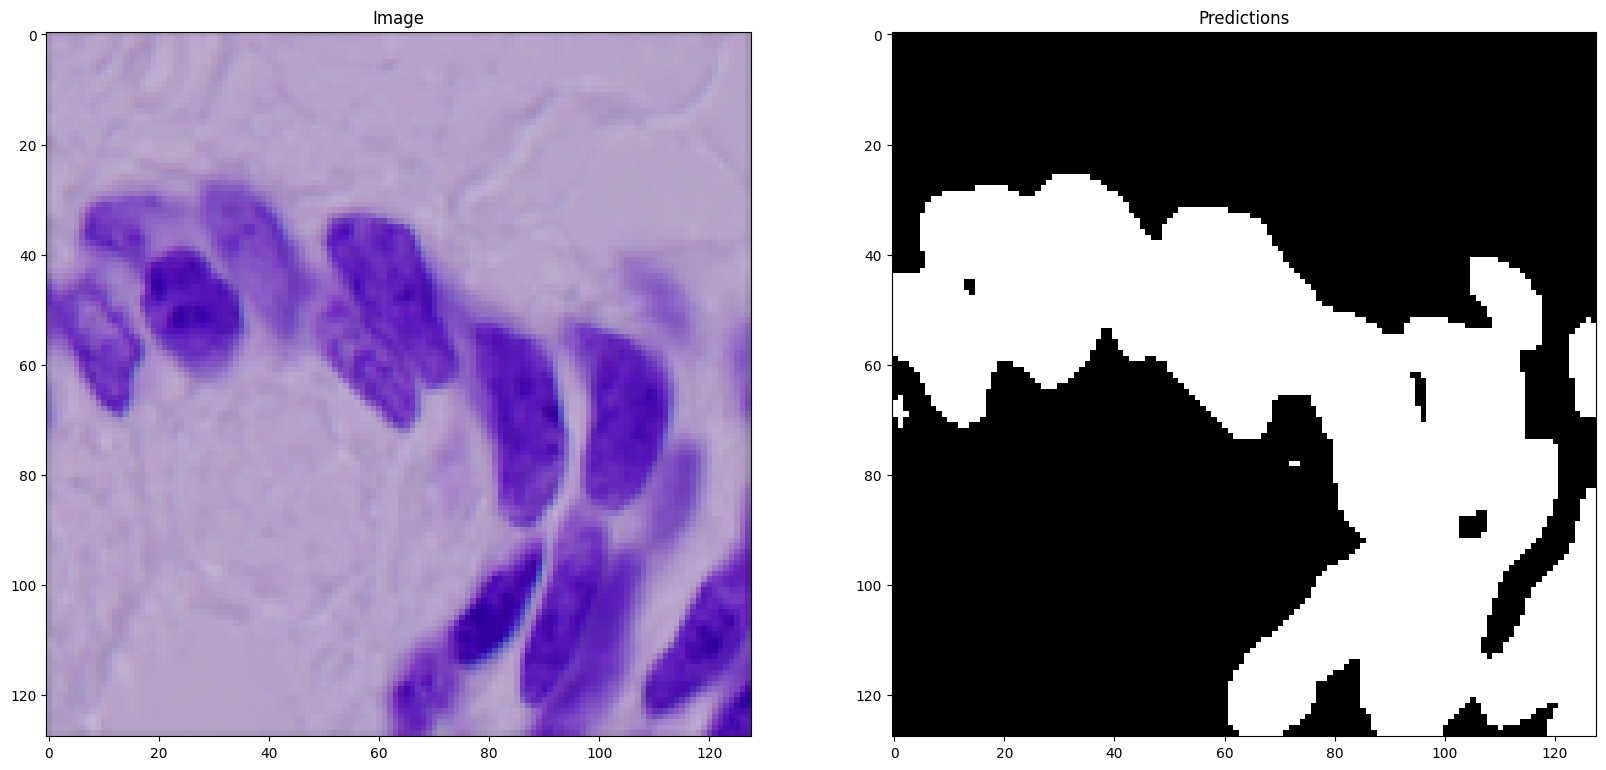

In [13]:
# Ploting our predicted masks
ix = random.randint(602, 668)
plt.figure(figsize=(20,20))

# Our original training image
plt.subplot(121)
plt.imshow(X_train[ix])
plt.title("Image")

# The mask our U-Net model predicts
plt.subplot(122)
ix = ix - 603
plt.imshow(np.squeeze(preds_val_t[ix] > 0.5), cmap='gray')
plt.title("Predictions")
plt.show()

In [17]:
from skimage.morphology import label

def iou_metric(y_true_in, y_pred_in, print_table=False):
    labels = label(y_true_in > 0.5)
    y_pred = label(y_pred_in > 0.5)

    true_objects = len(np.unique(labels))
    pred_objects = len(np.unique(y_pred))

    intersection = np.histogram2d(labels.flatten(), y_pred.flatten(), bins=(true_objects, pred_objects))[0]

    # Compute areas (needed for finding the union between all objects)
    area_true = np.histogram(labels, bins = true_objects)[0]
    area_pred = np.histogram(y_pred, bins = pred_objects)[0]
    area_true = np.expand_dims(area_true, -1)
    area_pred = np.expand_dims(area_pred, 0)

    # Compute union
    union = area_true + area_pred - intersection

    # Exclude background from the analysis
    intersection = intersection[1:,1:]
    union = union[1:,1:]
    union[union == 0] = 1e-9

    # Compute the intersection over union
    iou = intersection / union

    # Precision helper function
    def precision_at(threshold, iou):
        matches = iou > threshold
        true_positives = np.sum(matches, axis=1) == 1   # Correct objects
        false_positives = np.sum(matches, axis=0) == 0  # Missed objects
        false_negatives = np.sum(matches, axis=1) == 0  # Extra objects
        tp, fp, fn = np.sum(true_positives), np.sum(false_positives), np.sum(false_negatives)
        return tp, fp, fn

    # Loop over IoU thresholds
    prec = []
    if print_table:
        print("Thresh\tTP\tFP\tFN\tPrec.")
    for t in np.arange(0.5, 1, 0.05):
        tp, fp, fn = precision_at(t, iou)
        if (tp + fp + fn) > 0:
            p = tp / (tp + fp + fn)
        else:
            p = 0
        if print_table:
            print("{:1.3f}\t{}\t{}\t{}\t{:1.3f}".format(t, tp, fp, fn, p))
        prec.append(p)

    if print_table:
        print("AP\t-\t-\t-\t{:1.3f}".format(np.mean(prec)))
    return np.mean(prec)

def iou_metric_batch(y_true_in, y_pred_in):
    batch_size = y_true_in.shape[0]
    metric = []
    for batch in range(batch_size):
        value = iou_metric(y_true_in[batch], y_pred_in[batch])
        metric.append(value)
    return np.array(np.mean(metric), dtype=np.float32)

def my_iou_metric(label, pred):
    metric_value = tf.py_func(iou_metric_batch, [label, pred], tf.float32)
    return metric_value

iou_metric(np.squeeze(Y_train[ix]), np.squeeze(preds_train_t[ix]), print_table=True)

Thresh	TP	FP	FN	Prec.
0.500	16	0	0	1.000
0.550	16	0	0	1.000
0.600	16	0	0	1.000
0.650	16	0	0	1.000
0.700	16	0	0	1.000
0.750	16	0	0	1.000
0.800	16	0	0	1.000
0.850	15	1	1	0.882
0.900	15	1	1	0.882
0.950	10	6	6	0.455
AP	-	-	-	0.922


np.float64(0.9219251336898397)